**Note on commit identifiers (added 2026-09-24).**

This report's recorded results and content are unchanged. The commit hashes cited below, in stored tables and in code cells, refer to pre-rewrite history that is no longer reachable from master. The old-to-new correspondence is recorded in DECISIONS.md, section "Repository history rewrite (trailer removal), 2026-09-24". The notebook was not regenerated to replace them.

# WattCast - Phase 4: sequence modelling (LSTM)

Report over committed artifacts only (`results/*.json`, the predictions CSV, the golden fixture, `DECISIONS.md`, git metadata). Trains and evaluates nothing.

- [S1](#S1-Summary) [S2](#S2-Provenance) [S3](#S3-Inherited-context) [S4](#S4-Design-decisions) [S5](#S5-Failures)
- [S6](#S6-Protocol) [S7](#S7-Pre-run-measurements) [S8](#S8-Validation-tuning) [S9](#S9-Final-evaluation)
- [S10](#S10-Exploratory) [S11](#S11-Limits) [S12](#S12-Reproduce) [S13](#S13-Whats-next)

In [1]:
%matplotlib inline
import json
import subprocess
import sys
import importlib.metadata as im
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
assert (ROOT / "DECISIONS.md").exists()

RESULTS = ROOT / "results"
FIXTURES = ROOT / "tests" / "fixtures"

tuning = json.loads((RESULTS / "tuning_h6_validation.json").read_text())
final = json.loads((RESULTS / "final_evaluation.json").read_text())
golden = json.loads((FIXTURES / "golden_baselines.json").read_text())
decisions = (ROOT / "DECISIONS.md").read_text()

BASELINE_ORDER = ["naive_persistence", "naive_seasonal", "linear_regression", "random_forest"]
MODEL_ORDER = BASELINE_ORDER + ["LSTM"]

COLORS = {
    "naive_persistence": "#0072B2",
    "naive_seasonal": "#D55E00",
    "linear_regression": "#009E73",
    "random_forest": "#CC79A7",
    "LSTM": "#E69F00",
}
SEED_COLORS = {42: "#0072B2", 43: "#D55E00", 44: "#009E73"}


def git(*args):
    result = subprocess.run(["git", *args], cwd=ROOT, capture_output=True, text=True)
    result.check_returncode()
    return result.stdout.strip()

In [2]:
tier1_shown = final["tier1"]["shown"]
n_test_evals = sum(len(final["horizons"][h]["runs"]) for h in final["horizons"])
verdict_word = "SHOWN" if tier1_shown else "NOT SHOWN"
display(Markdown(
    f"**Tier 1 verdict:** {verdict_word}  \n"
    f"**LSTM test evaluations recorded (all seeds x horizons):** {n_test_evals}"
))

**Tier 1 verdict:** NOT SHOWN  
**LSTM test evaluations recorded (all seeds x horizons):** 6

## S1 Summary

Purpose: state the primary question, the selected configuration, and the headline validation/test/Tier-1 numbers, all computed from the artifacts.

Evidence: `results/tuning_h6_validation.json`, `results/final_evaluation.json`.

In [3]:
sel = tuning["selected"]
lr_val_ref = tuning["reference"]
lr_test_ref = final["baselines"]["linear_regression|h6"]
lstm_h6 = final["horizons"]["6"]["summary"]
test_mae_ratio = lstm_h6["test_mae"]["mean"] / lr_test_ref["test_mae"]
test_rmse_ratio = lstm_h6["test_rmse"]["mean"] / lr_test_ref["test_rmse"]

summary_rows = [
    ("Primary horizon", "h=6 (1 hour)"),
    ("Reference baseline", "linear_regression"),
    ("Selected max_epochs", sel["max_epochs"]),
    ("Selected huber_delta (Wh)", sel["huber_delta"]),
    ("Validation MAE ratio (LSTM / linear_regression)", round(sel["val_mae_ratio"], 4)),
    ("Validation RMSE ratio (LSTM / linear_regression)", round(sel["val_rmse_ratio"], 4)),
    ("Test MAE ratio (LSTM / linear_regression)", round(test_mae_ratio, 4)),
    ("Test RMSE ratio (LSTM / linear_regression)", round(test_rmse_ratio, 4)),
    ("Tier 1 verdict", "SHOWN" if final["tier1"]["shown"] else "NOT SHOWN"),
]
for seed_res in final["tier1"]["per_seed"]:
    summary_rows.append((f"Tier 1 pass, seed {seed_res['seed']}", seed_res["pass"]))
display(pd.DataFrame(summary_rows, columns=["Quantity", "Value"]))

,Quantity,Value
0,Primary horizon,h=6 (1 hour)
1,Reference baseline,linear_regression
2,Selected max_epochs,50
3,Selected huber_delta (Wh),40.0
4,Validation MAE ratio (LSTM / linear_regression),0.7849
5,Validation RMSE ratio (LSTM / linear_regression),0.973
6,Test MAE ratio (LSTM / linear_regression),0.9137
7,Test RMSE ratio (LSTM / linear_regression),1.0355
8,Tier 1 verdict,NOT SHOWN
9,"Tier 1 pass, seed 42",False


In [4]:
h1 = final["horizons"]["1"]["summary"]
h1_rows = [
    ("LSTM (seed mean)", h1["test_mae"]["mean"], h1["test_rmse"]["mean"]),
    ("linear_regression", final["baselines"]["linear_regression|h1"]["test_mae"], final["baselines"]["linear_regression|h1"]["test_rmse"]),
    ("naive_persistence", final["baselines"]["naive_persistence|h1"]["test_mae"], final["baselines"]["naive_persistence|h1"]["test_rmse"]),
]
display(pd.DataFrame(h1_rows, columns=["Model", "Test MAE (Wh)", "Test RMSE (Wh)"]))
display(Markdown("**Outcome:** h=1 is secondary/reporting only; no Tier 1 rule applies to it."))

,Model,Test MAE (Wh),Test RMSE (Wh)
0,LSTM (seed mean),28.535189,65.440163
1,linear_regression,27.155402,59.712176
2,naive_persistence,26.496496,66.142080


**Outcome:** h=1 is secondary/reporting only; no Tier 1 rule applies to it.

## S2 Provenance

Purpose: record software versions and the commit ledger underlying this notebook's claims, each asserted to exist in this repository's history.

Evidence: `importlib.metadata`, `git cat-file`, `git log`.

In [5]:
pkgs = ["numpy", "pandas", "scikit-learn", "torch", "mlflow", "matplotlib"]
version_rows = [("python", sys.version.split()[0])]
for pkg in pkgs:
    try:
        version_rows.append((pkg, im.version(pkg)))
    except im.PackageNotFoundError:
        version_rows.append((pkg, "not installed"))
version_rows.append(("venv", Path(sys.prefix).name))
version_df = pd.DataFrame(version_rows, columns=["Package", "Version"])
display(version_df)
torch_version = dict(version_rows)["torch"]
assert torch_version == "2.14.0+cpu", torch_version
display(Markdown("**Outcome:** the executing kernel matches the pinned CPU build of torch used for every Phase 4 run."))

,Package,Version
0,python,3.14.4
1,numpy,2.5.3
2,pandas,3.0.6
3,scikit-learn,1.9.1
4,torch,2.14.0+cpu
5,mlflow,3.16.1
6,matplotlib,3.11.2
7,venv,env


**Outcome:** the executing kernel matches the pinned CPU build of torch used for every Phase 4 run.

In [6]:
LEDGER = [
    ("82eb111", "regenerated processed CSVs + writer + artifact guard"),
    ("be746eb", "frozen golden baseline fixture (pre-change)"),
    ("7f0ffc6", "interface: required_history_length + harness-supplied context"),
    ("d384b53", "two-tier golden bar"),
    ("6b66838", "purge function"),
    ("f0bb301", "harness excludes label-ineligible train rows"),
    ("55c532c", "purge wired into run_pipeline"),
    ("c4c9583", "purged processed data + regenerated golden fixture"),
    ("f95f3f5", "torch 2.14.0+cpu pinned"),
    ("4403f99", "make_windows"),
    ("318c091", "SequenceDataset"),
    ("f31c3aa", "PRE-REGISTRATION of the evaluation protocol"),
    ("6655b54", "LSTM forecaster implementation"),
    ("a7cfb2f", "selection rule + reference loader"),
    ("d6351d7", "pre-run measurements entry"),
    ("2325bd5", "validation-only isolation decision entry"),
    ("ab1d592", "validation-only evaluator"),
    ("d82a40e", "validation-only grid runner"),
    ("c24fa69", "validation grid results (36 fits)"),
    ("2cfaa55", "final-evaluation module (one-shot)"),
    ("0c685de", "final evaluation results"),
    ("3fee6fa", "results entry in DECISIONS.md"),
    ("fce1d88", "exploratory predicted-vs-actual plot"),
]
ledger_rows = []
for sha, role in LEDGER:
    git("cat-file", "-e", f"{sha}^{{commit}}")
    subject = git("log", "-1", "--format=%s", sha)
    ledger_rows.append((sha, subject, role))
ledger_df = pd.DataFrame(ledger_rows, columns=["sha", "subject", "role"])
display(ledger_df)

,sha,subject,role
0,82eb111,data: regenerate processed CSVs with baseline ...,regenerated processed CSVs + writer + artifact...
1,be746eb,test: freeze golden baseline metrics (pre-inte...,frozen golden baseline fixture (pre-change)
2,7f0ffc6,feat(eval): declared history context for seque...,interface: required_history_length + harness-s...
3,d384b53,test: two-tier golden bar; linear regression t...,two-tier golden bar
4,6b66838,feat(data): mask_ineligible_labels for labels ...,purge function
5,f0bb301,feat(eval): harness excludes label-ineligible ...,harness excludes label-ineligible train rows
6,55c532c,feat(pipeline): mask train labels that point p...,purge wired into run_pipeline
7,c4c9583,data: regenerate processed CSVs with purged tr...,purged processed data + regenerated golden fix...
8,f95f3f5,build: pin torch 2.14.0+cpu via the PyTorch CP...,torch 2.14.0+cpu pinned
9,4403f99,"feat(models): make_windows, the single causal ...",make_windows


In [7]:
AUDIT_PAIRS = [
    ("f31c3aa", "6655b54", "protocol before code"),
    ("f31c3aa", "c24fa69", "protocol before validation result"),
    ("c24fa69", "2cfaa55", "validation result before the module that reads test data"),
    ("2cfaa55", "0c685de", "module before its results"),
]
audit_rows = []
for ancestor, descendant, meaning in AUDIT_PAIRS:
    subprocess.run(
        ["git", "merge-base", "--is-ancestor", ancestor, descendant], cwd=ROOT, check=True
    )
    audit_rows.append((ancestor, descendant, meaning, "OK"))
display(pd.DataFrame(audit_rows, columns=["ancestor", "descendant", "meaning", "check"]))

,ancestor,descendant,meaning,check
0,f31c3aa,6655b54,protocol before code,OK
1,f31c3aa,c24fa69,protocol before validation result,OK
2,c24fa69,2cfaa55,validation result before the module that reads...,OK
3,2cfaa55,0c685de,module before its results,OK


## S3 Inherited context (Phases 0-3)

- Dataset: UCI Appliances Energy Prediction, 19,735 rows at 10-minute spacing, 2016-01-11 to 2016-05-27.
- Split by calendar day: train before 2016-04-18, validation 2016-04-18 to 2016-04-30, test from 2016-04-30.
- Horizons: h=1 (10 minutes) and h=6 (1 hour, primary).

Outcome: the table below is the full set of Phase 3 baseline results this notebook compares LSTM against, in fixed model order.

In [8]:
def baseline_table(horizon_suffix):
    rows = []
    for model in BASELINE_ORDER:
        entry = golden["results"][f"{model}|{horizon_suffix}"]["metrics"]
        rows.append((model, entry["val_mae"], entry["val_rmse"], entry["test_mae"], entry["test_rmse"]))
    return pd.DataFrame(rows, columns=["Model", "Val MAE (Wh)", "Val RMSE (Wh)", "Test MAE (Wh)", "Test RMSE (Wh)"])

display(Markdown("**h=6 (primary)**"))
display(baseline_table("h6"))
display(Markdown("**h=1 (secondary)**"))
display(baseline_table("h1"))

**h=6 (primary)**

,Model,Val MAE (Wh),Val RMSE (Wh),Test MAE (Wh),Test RMSE (Wh)
0,naive_persistence,49.160880,107.422722,47.599599,103.624735
1,naive_seasonal,48.750000,108.038059,53.775996,112.358377
2,linear_regression,44.415983,81.931009,42.391318,80.618737
3,random_forest,41.939988,78.630403,45.118216,83.064979


**h=1 (secondary)**

,Model,Val MAE (Wh),Val RMSE (Wh),Test MAE (Wh),Test RMSE (Wh)
0,naive_persistence,25.243056,65.304663,26.496496,66.142080
1,naive_seasonal,48.750000,108.036988,53.718719,112.289175
2,linear_regression,26.155821,58.748734,27.155402,59.712176
3,random_forest,29.398681,59.946358,32.459559,65.866056


## S4 Design decisions

Purpose: the design decisions made during Phase 4, each with rejected alternatives, the evidence behind it, and the commit(s) it landed in.

Evidence: this notebook's own text below, cross-checked against git (every commit is asserted to exist).

In [9]:
DECISIONS_TABLE = [
    ("D0", "Regenerate stale processed CSVs from code; add writer and artifact guard test",
     "patch the generator around missing columns",
     "committed CSVs lacked Appliances_lag_143/138 (golden generator KeyError); shared columns and scaler verified identical before install",
     "82eb111"),
    ("D1", "Model declares required_history_length (default 0); harness prepends the tail of the preceding partition and audits that exactly the first k outputs are NaN",
     "context stored inside the adapter; optional context=None argument",
     "a stored train tail is right for one partition only and depends on call order; an optional-but-required argument breaks substitutability",
     "7f0ffc6"),
    ("D2", "Label purge, choice A: keep the last h train rows as feature/context rows, set their labels to NaN, exclude them from fit and train scoring",
     "delete the rows (opens a gap in validation context)",
     "their labels point into the validation period (1 row at h=1, 6 at h=6)",
     "6b66838, f0bb301, 55c532c, c4c9583"),
    ("D3", "Golden fixture with a two-tier bar: counts exact; metrics exact except linear_regression at relative 1e-12",
     "force Fortran layout in the harness; loosen everything",
     "BLAS summation order depends on input memory layout (~1e-16 relative in metrics, up to 4.3e-13 in predictions)",
     "be746eb, d384b53"),
    ("D4", "One numpy windowing function (make_windows) shared by training and inference; returns an independent C-contiguous copy",
     "np.ascontiguousarray on the transposed view",
     "measured: it aliases the input at L=1 and L=n",
     "4403f99"),
    ("D5", "SequenceDataset owns float32 tensors; item = (L,16) window + scalar target y[i+L-1]; loud validation",
     "torch.from_numpy(y[L-1:])",
     "measured: it aliases the caller's array",
     "318c091"),
    ("D6", "LSTM input = FEATURE_COLUMNS minus hour_of_day and day_of_week (16 columns, is_weekend kept); no raw Appliances",
     "all 18 columns; add Appliances",
     "7 of 18 columns are unscaled (0-23 integers would saturate gates); Appliances[t] is recoverable from roll6_mean and lags 1-5",
     "6655b54"),
    ("D7", "Target in raw Wh; output bias initialised to the median of the y passed to fit",
     "zero init; target scaling",
     "zero init needs ~60,000 Adam steps to reach 60 Wh vs ~10,850 available; no persisted scaler",
     "6655b54"),
    ("D8", "Fixed epoch budget selected on validation; no early stopping; no inner holdout",
     "early stopping on an inner validation tail",
     "an inner tail creates a second label boundary that needs its own purge",
     "f31c3aa"),
    ("D9", "Huber loss, delta selected on validation from [20, 40, 60] Wh",
     "delta=20 by intuition",
     "at h=6 only 45% of linear_regression validation residuals fall within 20 Wh",
     "f31c3aa"),
    ("D10", "Seeded fork_rng + local generator; thread count is a recorded parameter (4)",
     "global seeding; default threads",
     "measured: identical 4-thread fits are bitwise equal; a 1-thread fit differs",
     "6655b54, d6351d7"),
    ("D11", "Selection score = max(val MAE ratio, val RMSE ratio) vs the linear_regression validation reference; lexicographic tie-break, no tolerance band",
     "RMSE-only; a 0.5% tie band",
     "selection must target the same two-metric objective as the success rule",
     "f31c3aa, a7cfb2f"),
    ("D12", "Protocol pre-registered before any LSTM code; Tier 1 needs all three seeds to beat the unrounded linear_regression h=6 test MAE and RMSE by 1%",
     "decide the rule after seeing results",
     "a post-hoc rule is unfalsifiable",
     "f31c3aa"),
    ("D13", "Tuning is structurally validation-only (Option 2): separate evaluator and runner that receive no test data; equivalence-tested against the harness",
     "reuse the three-partition harness and ignore its test fields",
     "\"never read\" becomes something a test demonstrates",
     "2325bd5, ab1d592, d82a40e"),
    ("D14", "Final evaluation is one-shot: registered seeds and horizons are constants, refuses to overwrite, exits 0 whether or not Tier 1 is shown",
     "a re-runnable script",
     "a registered outcome must not look like a failure that invites reruns",
     "2cfaa55, 0c685de"),
]
decisions_df = pd.DataFrame(DECISIONS_TABLE, columns=["ID", "Decision", "Alternatives rejected", "Evidence", "Commit(s)"])
for commits in decisions_df["Commit(s)"]:
    for sha in [c.strip() for c in commits.split(",")]:
        git("cat-file", "-e", f"{sha}^{{commit}}")
display(decisions_df)

,ID,Decision,Alternatives rejected,Evidence,Commit(s)
0,D0,Regenerate stale processed CSVs from code; add...,patch the generator around missing columns,committed CSVs lacked Appliances_lag_143/138 (...,82eb111
1,D1,Model declares required_history_length (defaul...,context stored inside the adapter; optional co...,a stored train tail is right for one partition...,7f0ffc6
2,D2,"Label purge, choice A: keep the last h train r...",delete the rows (opens a gap in validation con...,their labels point into the validation period ...,"6b66838, f0bb301, 55c532c, c4c9583"
3,D3,Golden fixture with a two-tier bar: counts exa...,force Fortran layout in the harness; loosen ev...,BLAS summation order depends on input memory l...,"be746eb, d384b53"
4,D4,One numpy windowing function (make_windows) sh...,np.ascontiguousarray on the transposed view,measured: it aliases the input at L=1 and L=n,4403f99
5,D5,SequenceDataset owns float32 tensors; item = (...,torch.from_numpy(y[L-1:]),measured: it aliases the caller's array,318c091
6,D6,LSTM input = FEATURE_COLUMNS minus hour_of_day...,all 18 columns; add Appliances,7 of 18 columns are unscaled (0-23 integers wo...,6655b54
7,D7,Target in raw Wh; output bias initialised to t...,zero init; target scaling,"zero init needs ~60,000 Adam steps to reach 60...",6655b54
8,D8,Fixed epoch budget selected on validation; no ...,early stopping on an inner validation tail,an inner tail creates a second label boundary ...,f31c3aa
9,D9,"Huber loss, delta selected on validation from ...",delta=20 by intuition,at h=6 only 45% of linear_regression validatio...,f31c3aa


## S5 Failures found and how they were caught

Purpose: record defects surfaced during Phase 4 development, how each was detected, and its resolution commit.

In [10]:
FAILURES_TABLE = [
    ("F1", "stale processed CSVs", "golden generator KeyError", "writer + guard test (failed 6/6 on stale data first)", "82eb111"),
    ("F2", "leftover line after a harness edit (NameError, 7 failing tests)", "full suite", "line removed", "7f0ffc6"),
    ("F3", "one intermediate commit had a failing golden test (strict bar)", "noticed after committing", "fixed by the next commit; left in history", "7f0ffc6, d384b53"),
    ("F4", "aliasing traps (make_windows at L=1/L=n; from_numpy on float32/float64 targets)", "variant runs against the tests", "copy-always implementations + tests", "4403f99, 318c091"),
    ("F5", "a failed refit left a half-updated model", "red test before the fix", "fitted state assigned only after training succeeds", "6655b54"),
    ("F6", "bit-for-bit linear_regression test does not detect a Fortran-ordered input (measured at 100 and 1,728 rows)", "in-memory variant run", "claim removed from the commit message; logged as a limit", "ab1d592"),
    ("F7", "duplicate, contradictory protocol entry in DECISIONS.md", "diff review", "superseded draft removed before committing", "f31c3aa"),
    ("F8", "polling loop matched its own command line (pgrep -f)", "loop never ended", "PID + kill -0", "process"),
    ("F9", "relayed tool output corrupted (a duplicated line; a fragment that no command could produce)", "internal inconsistency", "verbatim re-run", "process"),
    ("F10", "default-index torch dry run killed (exit 137, likely memory)", "dry run", "CPU wheel via --extra-index-url pin", "f95f3f5"),
]
failures_df = pd.DataFrame(FAILURES_TABLE, columns=["ID", "Issue", "How found", "Resolution", "Commit"])
for commits in failures_df["Commit"]:
    for sha in [c.strip() for c in commits.split(",")]:
        if sha == "process":
            continue
        git("cat-file", "-e", f"{sha}^{{commit}}")
display(failures_df)

,ID,Issue,How found,Resolution,Commit
0,F1,stale processed CSVs,golden generator KeyError,writer + guard test (failed 6/6 on stale data ...,82eb111
1,F2,"leftover line after a harness edit (NameError,...",full suite,line removed,7f0ffc6
2,F3,one intermediate commit had a failing golden t...,noticed after committing,fixed by the next commit; left in history,"7f0ffc6, d384b53"
3,F4,aliasing traps (make_windows at L=1/L=n; from_...,variant runs against the tests,copy-always implementations + tests,"4403f99, 318c091"
4,F5,a failed refit left a half-updated model,red test before the fix,fitted state assigned only after training succ...,6655b54
5,F6,bit-for-bit linear_regression test does not de...,in-memory variant run,claim removed from the commit message; logged ...,ab1d592
6,F7,"duplicate, contradictory protocol entry in DEC...",diff review,superseded draft removed before committing,f31c3aa
7,F8,polling loop matched its own command line (pgr...,loop never ended,PID + kill -0,process
8,F9,relayed tool output corrupted (a duplicated li...,internal inconsistency,verbatim re-run,process
9,F10,"default-index torch dry run killed (exit 137, ...",dry run,CPU wheel via --extra-index-url pin,f95f3f5


## S6 Pre-registered protocol

Purpose: state the pre-registered tuning grid, the selection rule, and the isolation rule, sourced from the artifacts and cross-checked against `DECISIONS.md`.

In [11]:
proto = tuning["protocol"]
protocol_rows = [
    ("Seeds", proto["seeds"]),
    ("max_epochs grid", proto["epochs"]),
    ("huber_delta grid (Wh)", proto["deltas"]),
    ("Configurations", len(tuning["configurations"])),
    ("Fits (configurations x seeds)", len(tuning["runs"])),
    ("Tier 1 factor", final["protocol"]["tier1_factor"]),
    ("Tier 1 threshold MAE (Wh)", round(final["tier1_reference"]["threshold_mae"], 3)),
    ("Tier 1 threshold RMSE (Wh)", round(final["tier1_reference"]["threshold_rmse"], 3)),
]
display(pd.DataFrame(protocol_rows, columns=["Quantity", "Value"]))

rule_rows = [
    ("Selection formula", "selection_score = max(val_mae_ratio, val_rmse_ratio), each ratio vs the linear_regression validation reference"),
    ("Tie-break order", "lowest selection_score, then lowest val_mae_ratio, then lowest val_rmse_ratio, then lower max_epochs, then lower huber_delta"),
    ("Isolation rule", "the tuning path reads only val_* fields from the reference and the runs; no test metric or prediction is read, persisted, or logged"),
]
display(pd.DataFrame(rule_rows, columns=["Rule", "Statement"]))

for substr in ["## Phase 4: LSTM evaluation protocol (pre-registration)", "Reference separation"]:
    assert substr in decisions, substr
display(Markdown("**Outcome:** the protocol text quoted above is present in `DECISIONS.md`, and the grid/threshold numbers match the artifacts."))

,Quantity,Value
0,Seeds,"[42, 43, 44]"
1,max_epochs grid,"[10, 20, 35, 50]"
2,huber_delta grid (Wh),"[20.0, 40.0, 60.0]"
3,Configurations,12
4,Fits (configurations x seeds),36
5,Tier 1 factor,0.99
6,Tier 1 threshold MAE (Wh),41.967
7,Tier 1 threshold RMSE (Wh),79.813


,Rule,Statement
0,Selection formula,"selection_score = max(val_mae_ratio, val_rmse_..."
1,Tie-break order,"lowest selection_score, then lowest val_mae_ra..."
2,Isolation rule,the tuning path reads only val_* fields from t...


**Outcome:** the protocol text quoted above is present in `DECISIONS.md`, and the grid/threshold numbers match the artifacts.

## S7 Pre-run measurements

Purpose: the timing, memory, and repeatability measurements taken before any tuning run, as recorded in `DECISIONS.md`.

In [12]:
MEASUREMENTS_TABLE = [
    ("4-thread repeatability", "two independent 4-thread fits produced bitwise-identical predictions and per-epoch losses"),
    ("1-thread vs 4-thread difference", "predictions differed by up to 35.36 Wh after 3 epochs; cause not isolated"),
    ("Wall time per epoch", "0.65-1.16 s/epoch"),
    ("Peak process RSS", "approximately 570 MB"),
]
display(pd.DataFrame(MEASUREMENTS_TABLE, columns=["Measurement", "Finding"]))

for phrase in ["bitwise-identical predictions", "35.36 Wh", "0.65-1.16 s/epoch", "approximately 570 MB", "was not isolated"]:
    assert phrase in decisions, phrase
display(Markdown("**Outcome:** every phrase in the table above is a verbatim substring of `DECISIONS.md`."))

,Measurement,Finding
0,4-thread repeatability,two independent 4-thread fits produced bitwise...
1,1-thread vs 4-thread difference,predictions differed by up to 35.36 Wh after 3...
2,Wall time per epoch,0.65-1.16 s/epoch
3,Peak process RSS,approximately 570 MB


**Outcome:** every phrase in the table above is a verbatim substring of `DECISIONS.md`.

## S8 Validation tuning (h=6)

Purpose: show the full 4x3 grid searched on validation only, and the configuration it selected.

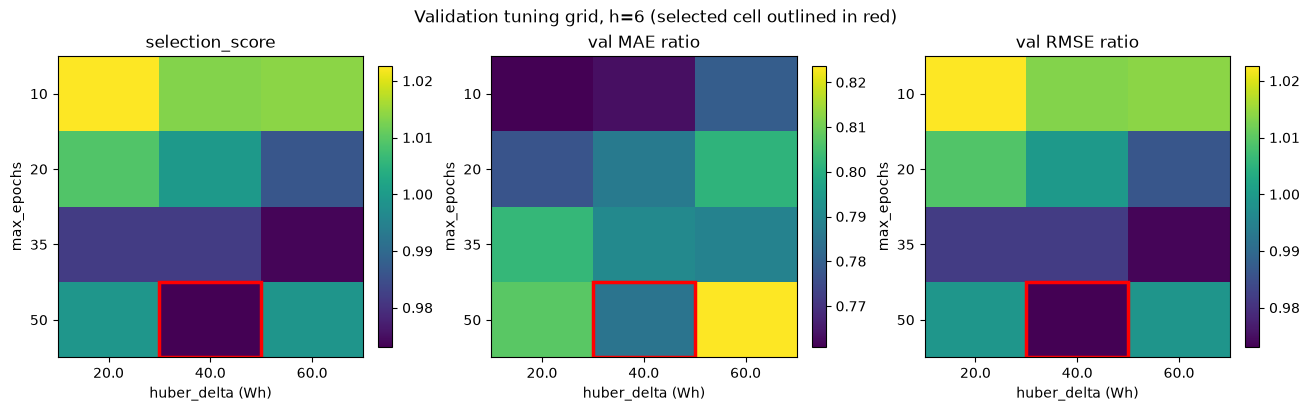

In [13]:
runs_df = pd.DataFrame(tuning["runs"])
assert len(runs_df) == 36
assert (runs_df["n_evaluated"] == 1728).all()
assert (runs_df["n_warmup_rows"] == 17).all()
assert (runs_df["n_ineligible_label_rows"] == 6).all()

epochs_order = proto["epochs"]
deltas_order = proto["deltas"]
configs_df = pd.DataFrame(tuning["configurations"])

def pivot(metric):
    return configs_df.pivot(index="max_epochs", columns="huber_delta", values=metric).reindex(index=epochs_order, columns=deltas_order)

score_grid = pivot("selection_score")
mae_grid = pivot("val_mae_ratio")
rmse_grid = pivot("val_rmse_ratio")

sel_epoch, sel_delta = sel["max_epochs"], sel["huber_delta"]
sel_row = epochs_order.index(sel_epoch)
sel_col = deltas_order.index(sel_delta)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
for ax, grid, title in zip(axes, [score_grid, mae_grid, rmse_grid], ["selection_score", "val MAE ratio", "val RMSE ratio"]):
    im_ = ax.imshow(grid.values, cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(deltas_order)), deltas_order)
    ax.set_yticks(range(len(epochs_order)), epochs_order)
    ax.set_xlabel("huber_delta (Wh)")
    ax.set_ylabel("max_epochs")
    ax.set_title(title)
    rect = plt.Rectangle((sel_col - 0.5, sel_row - 0.5), 1, 1, fill=False, edgecolor="red", linewidth=2.5)
    ax.add_patch(rect)
    fig.colorbar(im_, ax=ax, fraction=0.046)
fig.suptitle("Validation tuning grid, h=6 (selected cell outlined in red)")
plt.show()

In [14]:
display(configs_df[["max_epochs", "huber_delta", "mean_val_mae", "mean_val_rmse", "val_mae_ratio", "val_rmse_ratio", "selection_score"]])
assert (configs_df["val_rmse_ratio"] >= configs_df["val_mae_ratio"]).all()

recomputed = configs_df.sort_values(
    by=["selection_score", "val_mae_ratio", "val_rmse_ratio", "max_epochs", "huber_delta"]
).iloc[0]
assert recomputed["max_epochs"] == sel["max_epochs"]
assert recomputed["huber_delta"] == sel["huber_delta"]

per_seed_sel = runs_df[(runs_df["max_epochs"] == sel_epoch) & (runs_df["huber_delta"] == sel_delta)][
    ["seed", "val_mae", "val_rmse"]
].sort_values("seed")
per_seed_sel.loc["mean"] = ["mean", per_seed_sel["val_mae"].mean(), per_seed_sel["val_rmse"].mean()]
per_seed_sel.loc["std (ddof=1)"] = ["std", per_seed_sel["val_mae"].iloc[:-1].astype(float).std(ddof=1), per_seed_sel["val_rmse"].iloc[:-1].astype(float).std(ddof=1)]
display(per_seed_sel)
display(Markdown(
    f"**Outcome:** all 12 configurations satisfy RMSE ratio >= MAE ratio; the lexicographic minimum recomputed from the "
    f"36 runs matches the recorded selection (max_epochs={int(sel['max_epochs'])}, huber_delta={sel['huber_delta']})."
))

,max_epochs,huber_delta,mean_val_mae,mean_val_rmse,val_mae_ratio,val_rmse_ratio,selection_score
0,10,20.0,33.790749,83.780035,0.760779,1.022568,1.022568
1,10,40.0,33.902149,83.022318,0.763287,1.013320,1.013320
2,10,60.0,34.614451,83.069458,0.779324,1.013895,1.013895
3,20,20.0,34.513818,82.685113,0.777059,1.009204,1.009204
4,20,40.0,34.940281,81.914686,0.786660,0.999801,0.999801
5,20,60.0,35.607706,80.808403,0.801687,0.986298,0.986298
6,35,20.0,35.647963,80.447204,0.802593,0.981890,0.981890
7,35,40.0,35.105330,80.450134,0.790376,0.981925,0.981925
8,35,60.0,35.031879,79.782461,0.788722,0.973776,0.973776
9,50,20.0,35.870287,81.854907,0.807599,0.999071,0.999071


,seed,val_mae,val_rmse
30,42,35.979824,82.488495
31,43,34.813220,78.439025
32,44,33.787957,78.235252
mean,mean,34.860334,79.720924
std (ddof=1),std,1.096693,2.398951


**Outcome:** all 12 configurations satisfy RMSE ratio >= MAE ratio; the lexicographic minimum recomputed from the 36 runs matches the recorded selection (max_epochs=50, huber_delta=40.0).

## S9 Final evaluation

Purpose: the pre-registered, one-shot test evaluation of the selected configuration, at h=6 (primary, decision-making) and h=1 (secondary, reporting only).

In [15]:
tier1 = final["tier1"]
tier1_rows = []
for row in tier1["per_seed"]:
    tier1_rows.append((row["seed"], row["mae_pass"], row["rmse_pass"], row["pass"]))
tier1_df = pd.DataFrame(tier1_rows, columns=["seed", "MAE <= threshold", "RMSE <= threshold", "seed passes"])
tier1_df.attrs["threshold_mae"] = tier1["threshold_mae"]
tier1_df.attrs["threshold_rmse"] = tier1["threshold_rmse"]
display(Markdown(f"Thresholds (0.99 x linear_regression test reference): MAE <= {tier1['threshold_mae']:.3f} Wh, RMSE <= {tier1['threshold_rmse']:.3f} Wh"))
display(tier1_df)

recomputed_pass = all(row["mae_pass"] and row["rmse_pass"] for row in tier1["per_seed"])
assert recomputed_pass == tier1["shown"]
display(Markdown(f"**Outcome:** Tier 1 verdict as computed from the per-seed pass/fail flags is **{'SHOWN' if tier1['shown'] else 'NOT SHOWN'}**; this is not softened or relabeled."))

Thresholds (0.99 x linear_regression test reference): MAE <= 41.967 Wh, RMSE <= 79.813 Wh

,seed,MAE <= threshold,RMSE <= threshold,seed passes
0,42,True,False,False
1,43,True,False,False
2,44,True,False,False


**Outcome:** Tier 1 verdict as computed from the per-seed pass/fail flags is **NOT SHOWN**; this is not softened or relabeled.

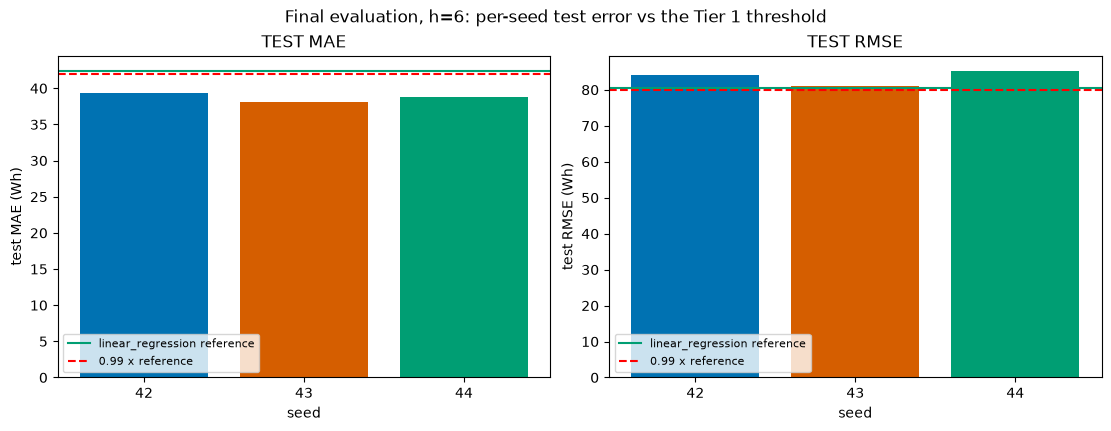

In [16]:
h6_runs = pd.DataFrame(final["horizons"]["6"]["runs"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
for ax, metric, ref_key in zip(axes, ["test_mae", "test_rmse"], ["test_mae", "test_rmse"]):
    seeds = h6_runs["seed"].tolist()
    values = h6_runs[metric].tolist()
    bar_colors = [SEED_COLORS[s] for s in seeds]
    ax.bar([str(s) for s in seeds], values, color=bar_colors)
    ref_val = lr_test_ref[ref_key]
    ax.axhline(ref_val, color=COLORS["linear_regression"], linestyle="-", label="linear_regression reference")
    ax.axhline(ref_val * final["protocol"]["tier1_factor"], color="red", linestyle="--", label="0.99 x reference")
    ax.set_xlabel("seed")
    ax.set_ylabel(f"{metric.upper().replace('TEST_', 'test ')} (Wh)")
    ax.set_title(metric.replace("test_", "test ").upper())
    ax.legend(fontsize=8)
fig.suptitle("Final evaluation, h=6: per-seed test error vs the Tier 1 threshold")
plt.show()

In [17]:
def tier2_table(horizon_key):
    runs = pd.DataFrame(final["horizons"][horizon_key]["runs"])[["seed", "test_mae", "test_rmse", "test_mape"]].sort_values("seed")
    runs.columns = ["seed", "MAE (Wh)", "RMSE (Wh)", "MAPE (%)"]
    summary = final["horizons"][horizon_key]["summary"]
    mean_row = pd.DataFrame([["mean", summary["test_mae"]["mean"], summary["test_rmse"]["mean"], summary["test_mape"]["mean"]]], columns=runs.columns)
    std_row = pd.DataFrame([["std (ddof=1)", summary["test_mae"]["std"], summary["test_rmse"]["std"], summary["test_mape"]["std"]]], columns=runs.columns)
    return pd.concat([runs, mean_row, std_row], ignore_index=True)

display(Markdown("**h=6 (primary)**"))
display(tier2_table("6"))
display(Markdown("**h=1 (secondary)**"))
display(tier2_table("1"))

**h=6 (primary)**

,seed,MAE (Wh),RMSE (Wh),MAPE (%)
0,42,39.312918,84.186753,33.017188
1,43,38.093617,81.016874,31.343540
2,44,38.787669,85.227839,31.639093
3,mean,38.731401,83.477155,31.999941
4,std (ddof=1),0.611595,2.193331,0.893271


**h=1 (secondary)**

,seed,MAE (Wh),RMSE (Wh),MAPE (%)
0,42,28.449427,65.403156,23.186107
1,43,28.456445,65.033952,23.638850
2,44,28.699694,65.883379,23.753523
3,mean,28.535189,65.440163,23.526160
4,std (ddof=1),0.142509,0.425921,0.300024


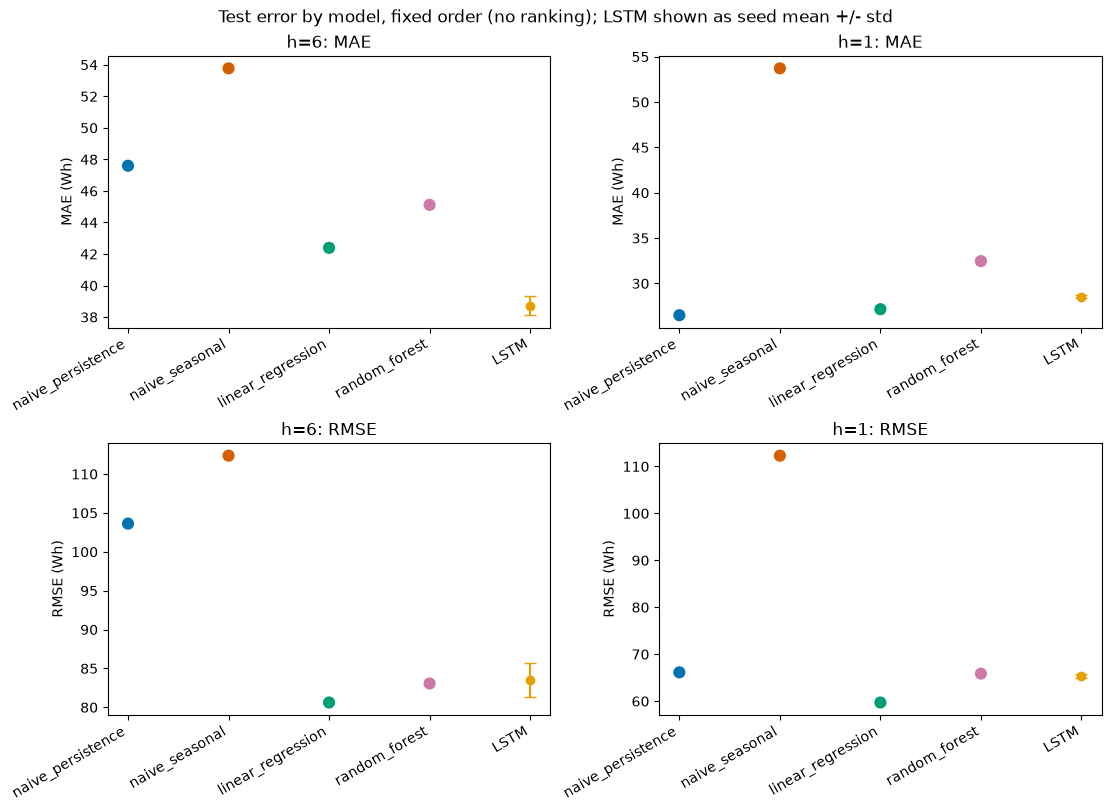

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
for col, hkey, hlabel in zip(range(2), ["6", "1"], ["h=6", "h=1"]):
    for row, metric in zip(range(2), ["test_mae", "test_rmse"]):
        ax = axes[row, col]
        xs, ys, colors_ = [], [], []
        for i, model in enumerate(BASELINE_ORDER):
            xs.append(i)
            ys.append(final["baselines"][f"{model}|h{hkey}"][metric])
            colors_.append(COLORS[model])
        ax.scatter(xs, ys, c=colors_, s=60, zorder=3)
        lstm_summary = final["horizons"][hkey]["summary"][metric]
        ax.errorbar(
            [len(BASELINE_ORDER)], [lstm_summary["mean"]], yerr=[lstm_summary["std"]],
            fmt="o", color=COLORS["LSTM"], capsize=4, zorder=3,
        )
        ax.set_xticks(range(len(MODEL_ORDER)), MODEL_ORDER, rotation=30, ha="right")
        ax.set_ylabel(f"{metric.replace('test_', '').upper()} (Wh)")
        ax.set_title(f"{hlabel}: {metric.replace('test_', '').upper()}")
fig.suptitle("Test error by model, fixed order (no ranking); LSTM shown as seed mean +/- std")
plt.show()

In [19]:
ratio_rows = []
for hkey in ["6", "1"]:
    val_ref = final["baselines"].get(f"linear_regression|h{hkey}")
    lstm_test = final["horizons"][hkey]["summary"]
    for metric in ["test_mae", "test_rmse"]:
        ratio_rows.append((f"h={hkey}", metric, lstm_test[metric]["mean"] / val_ref[metric]))
ratio_df = pd.DataFrame(ratio_rows, columns=["horizon", "metric", "LSTM seed mean / linear_regression test ratio"])
display(ratio_df)

n_test_h6 = h6_runs["n_evaluated"].iloc[0]["test"]
n_test_h1 = pd.DataFrame(final["horizons"]["1"]["runs"])["n_evaluated"].iloc[0]["test"]
assert n_test_h6 == 3991
assert n_test_h1 == 3996
assert n_test_evals == 6
display(Markdown(f"**Outcome:** {n_test_h6} test rows evaluated at h=6, {n_test_h1} at h=1, across {n_test_evals} total LSTM test evaluations (3 seeds x 2 horizons)."))

,horizon,metric,LSTM seed mean / linear_regression test ratio
0,h=6,test_mae,0.913664
1,h=6,test_rmse,1.035456
2,h=1,test_mae,1.050811
3,h=1,test_rmse,1.095927


**Outcome:** 3991 test rows evaluated at h=6, 3996 at h=1, across 6 total LSTM test evaluations (3 seeds x 2 horizons).

## S10 Exploratory predicted-vs-actual (exploratory, descriptive only)

Purpose: a purely descriptive look at two fixed windows of the h=6 test predictions. No new statistics or per-window metrics are computed.

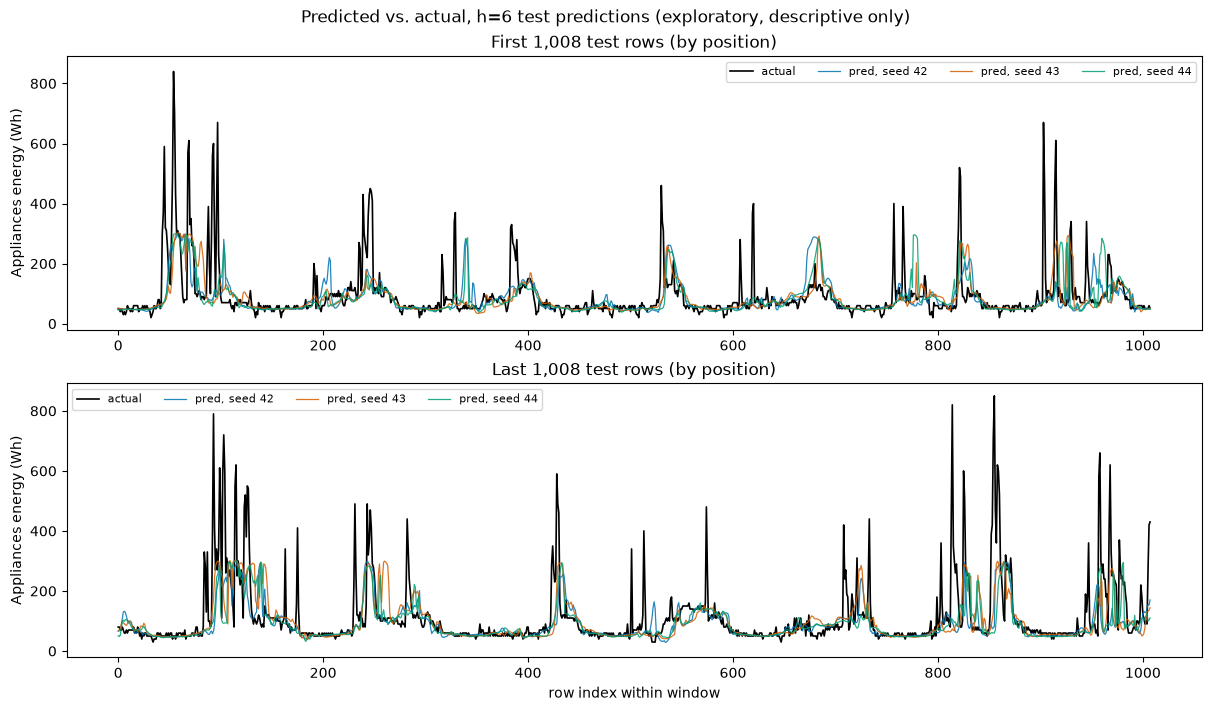

In [20]:
preds = pd.read_csv(RESULTS / "final_evaluation_predictions_h6.csv")
assert preds.shape == (3991, 5)
assert list(preds.columns) == ["date", "actual", "pred_seed_42", "pred_seed_43", "pred_seed_44"]

first_window = preds.iloc[:1008]
last_window = preds.iloc[-1008:]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharey=True, constrained_layout=True)
for ax, window, title in zip(axes, [first_window, last_window], ["First 1,008 test rows (by position)", "Last 1,008 test rows (by position)"]):
    x = range(len(window))
    ax.plot(x, window["actual"], color="black", linewidth=1.2, label="actual")
    for seed in [42, 43, 44]:
        ax.plot(x, window[f"pred_seed_{seed}"], color=SEED_COLORS[seed], linewidth=0.9, alpha=0.85, label=f"pred, seed {seed}")
    ax.set_title(title)
    ax.set_ylabel("Appliances energy (Wh)")
    ax.legend(fontsize=8, ncol=4)
axes[-1].set_xlabel("row index within window")
fig.suptitle("Predicted vs. actual, h=6 test predictions (exploratory, descriptive only)")
plt.show()

## S11 Limits and what is NOT concluded

- The selected configuration is the best of 12 by seed-mean validation score, so its validation score is optimistically biased (winner's curse).
- The two-metric selection score was decided by the RMSE ratio in all 12 configurations, not the MAE ratio.
- The validation seed spread is comparable in size to the margin the selection is decided by.
- Validation is the middle amplitude regime and test is the lowest (from the Phase 1 STL finding); no cause is claimed for any validation-to-test change.
- The last h validation labels point into the test period (at most 6 of 1,728 rows; never trained on).
- The bit-for-bit linear_regression test does not detect a Fortran-ordered input array; this non-detection is unexplained.
- `final_evaluation.py` is verified by tests and mechanical checks (git ancestry, one-shot guard), not read in full by this notebook.
- Phase 3 MLflow runs used unpurged data.
- Six LSTM test evaluations exist to date; any further use of the test partition needs a new dated registration.

In [21]:
for substr in [
    "best of 12 by seed-mean validation score",
    "decided by the RMSE ratio in all 12 configurations",
    "does not detect a Fortran-ordered input array",
    "### Not concluded",
]:
    assert substr in decisions, substr
display(Markdown("**Outcome:** every limit-bearing phrase above is a verbatim substring of `DECISIONS.md`."))

**Outcome:** every limit-bearing phrase above is a verbatim substring of `DECISIONS.md`.

## S12 Reproduce

| Step | Command |
| --- | --- |
| Environment | `pip install -r requirements.txt` (or `requirements-dev.txt` if present) |
| Tests | `python -m pytest -q` |
| Processed data | `python -m src.build_processed --out DIR` |
| Tuning | `python -m src.tuning.runner --train data/processed/train_t6.csv --val data/processed/val_t6.csv --reference tests/fixtures/golden_baselines.json --out results/tuning_h6_validation.json` |
| Final evaluation | `python -m src.evaluation.final_evaluation ...` (ONE-SHOT: refuses to overwrite `results/final_evaluation.json`; do not delete it to re-run; any re-run needs a new dated registration) |
| Plot | `python scripts/plot_final_predictions.py --predictions ... --out ...` |

## S13 What is next

- Phase 5: GRU and CNN-LSTM behind the same Forecaster contract used here.
- Walk-forward validation in place of the single calendar split.
- A new dated registration stating that six test evaluations already exist before any further test use.